# Network Science Assignment 7

Author:  
Elias Müller   
18-615-658

Submission Date:  
Monday, 11. November 2024

In [1]:
import matplotlib.pyplot as plt
import networkx as nx
import glob
import numpy as np
import random
from tqdm import tqdm
import igraph as ig


In [2]:
def initialize_figure(ROWS, COLS):
    fig, axes = plt.subplots(ROWS, COLS, figsize=(8 * COLS, 8 * ROWS))
    axes = axes.flatten()
    return fig, axes

# set the labels and the title of a given subplot ax
def set_ax_labels(ax, x_label, y_label, title):
    ax.set_xlabel(f"{x_label}")
    ax.set_ylabel(f"{y_label}")
    ax.set_title(f" {title}")

def clean_figure(fig, axes, start, end):
    for i in range(start, end):
        fig.delaxes(axes[i])


In [3]:
# load the data
data_paths = glob.glob("data/*.gml")
data_names = [str(x.replace("data/graph_", "")).replace(".gml", "") for x in data_paths]
data_lst = list(map(nx.read_gml, data_paths))

## Task 1
Generate synthetic networks:
- Random networks (Erdos–Rényi) (with n= 1000 and ⟨k⟩ = {1,4})
- Scale‑free networks (Barabási‑Albert) (with n=1000 and m= {2,4})

In [4]:
n = 1000
# generate erdos renyi
# given k: p = (k/(n-1))
er_graphs = {k: nx.erdos_renyi_graph(n, k/(n-1)) for k in [1,4]}
# generate barabasi_albert
ba_graphs = {k: nx.barabasi_albert_graph(n, k) for k in [2,4]}

## Task 2
Plot the degree distributions of the synthetic networks and of the networks provided in the
datasets

### Comments
The degree distributions of the Erdös-Renyi networks are plotted in linear scale and according binning, while the Barabasi-Albert networks and the provided datasets are plotted using logarithmic binning and scale.

Text(0.5, 0.95, 'Task 2 - Datasets')

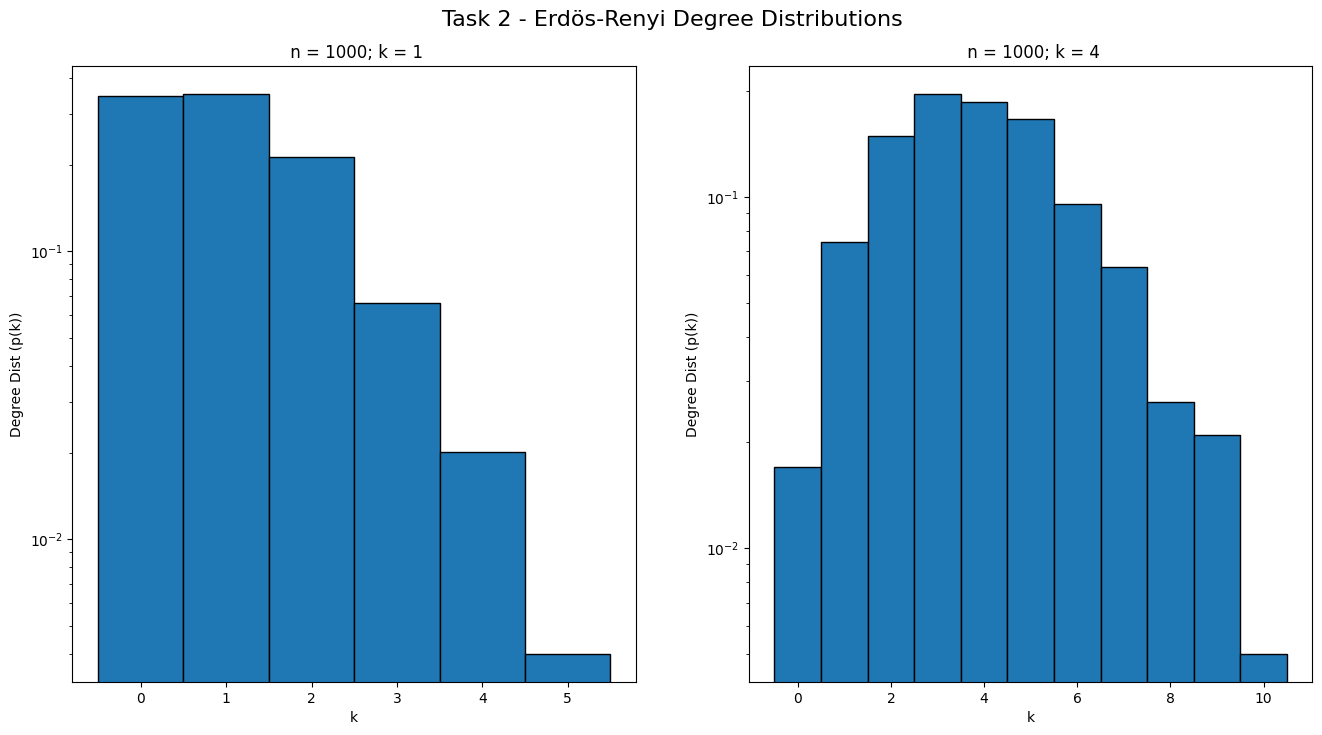

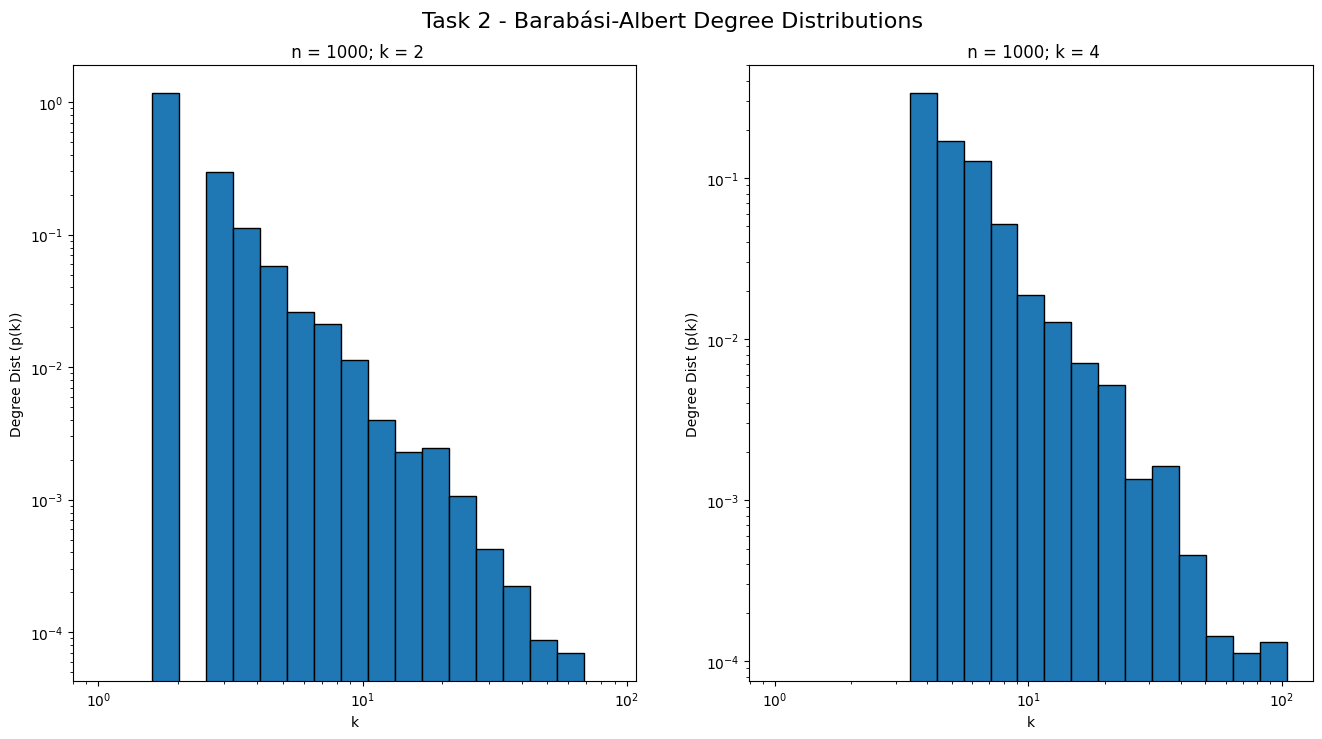

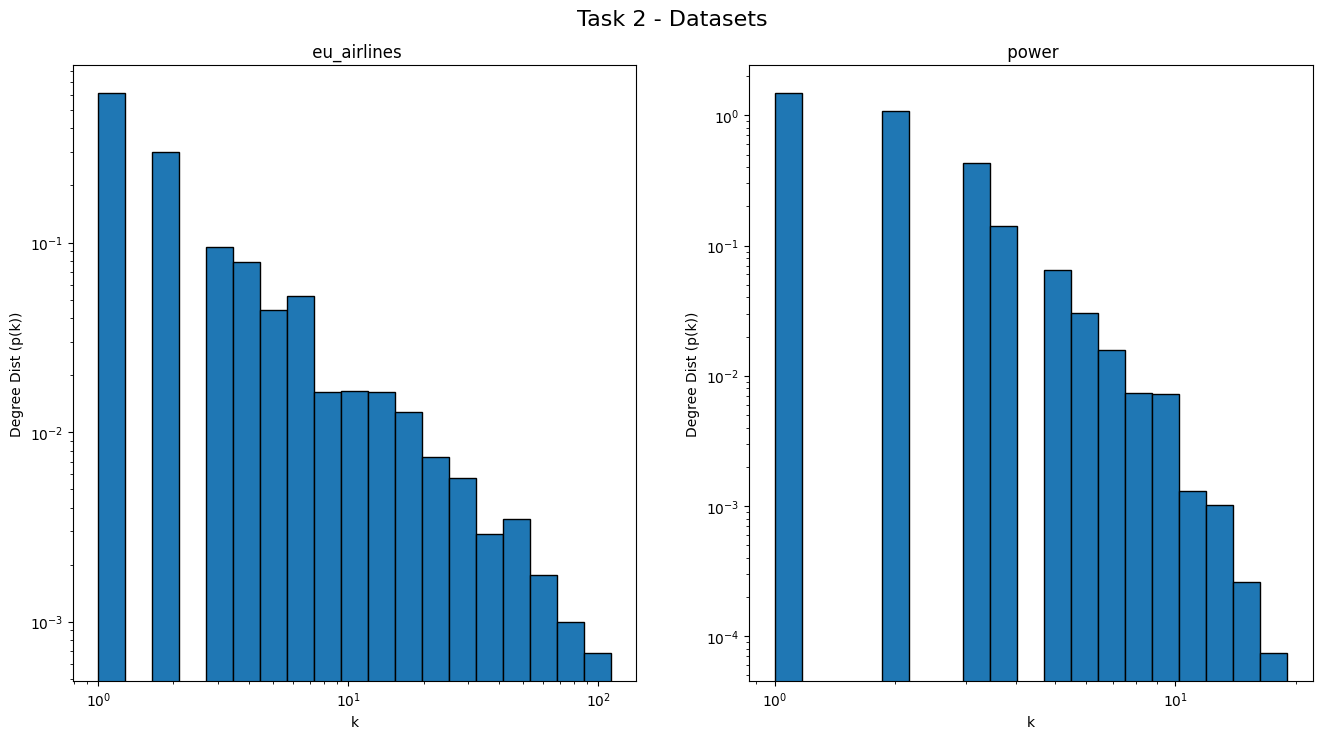

In [5]:
# plots the degree distribution against the degree using logarithmic binning
def plot_degree_dist(g, ax, title=None, log=True):
    degrees = list(dict(g.degree()).values())
    if log: 
        bins = np.logspace(np.log10(1), np.log10(max(degrees)), 20)    
        ax.set_xscale('log')
    else:
        bins = np.arange(0, max(degrees) + 1) - 0.5    

    ax.set_yscale('log')
    ax.hist(degrees, bins=bins, density=True, edgecolor='black') 

    set_ax_labels(ax, "k", "Degree Dist (p(k))", f"{title}")

# synthetic data erdos renyi
fig, axes = initialize_figure(1,2)

for i, (k, g) in enumerate(er_graphs.items()):
    plot_degree_dist(g, axes[i], title=f"n = 1000; k = {k}", log = False)

fig.suptitle("Task 2 - Erdös-Renyi Degree Distributions", fontsize=16, y=0.95)

# synthetic data barabasi_albert_graph
fig, axes = initialize_figure(1,2)

for i, (k, g) in enumerate(ba_graphs.items()):
    plot_degree_dist(g, axes[i], title=f"n = 1000; k = {k}")

fig.suptitle("Task 2 - Barabási-Albert Degree Distributions", fontsize=16, y=0.95)

clean_figure(fig, axes, len(ba_graphs), len(axes))

# datasets
fig, axes = initialize_figure(1,2)

for i, g in enumerate(data_lst):
    plot_degree_dist(g, axes[i], title=f"{data_names[i]}")

fig.suptitle("Task 2 - Datasets", fontsize=16, y=0.95)

## Task 3
Plot the size of the largest connected component as a function of removed edges and nodes in two scenarios for the synthetic graphs and the real networks in the datasets:
- Random attacks (failures)
- Targeted attacks (degree centrality and betweenness centrality)

### Comments
The majority of the measures (i.e. all except betweenness centrality) are computed using networkx. In order to speed up the computation of the betweenness and keep code readability, a different attack_function leveraging the i_graph library is implemented.

In [6]:

def attack_between(g):
    igg = ig.Graph.TupleList(g.edges(), directed=False)
    N = igg.vcount()
    largest_cc = max(len(component) for component in igg.connected_components())
    p0 = largest_cc
    removed_nodes = [(0, 1)]
    j = 0

    with tqdm(total=N, desc='Attacking nodes', unit='node') as pbar:
        while igg.vcount() > 0:
            betweenness = igg.betweenness()
            max_betweenness_value = max(betweenness)
            node_to_remove = betweenness.index(max_betweenness_value)   
                     
            igg.delete_vertices(node_to_remove)
            j += 1
            pbar.update(1)

            f = j / N
            largest_cc = max(len(component) for component in igg.connected_components())
            pf_p0 = largest_cc / p0
            removed_nodes.append((f, pf_p0))

            if largest_cc == 1:
                break

    x = [item[0] for item in removed_nodes]
    y = [item[1] for item in removed_nodes]
    return x, y

In [7]:
def size_largest_cc(G):
    return len(max(nx.connected_components(G), key=len))

def random_attack_node(g):
    return random.choice(list(g.nodes))

def random_attack_edge(g):
    return random.choice(list(g.edges))

def degree_centrality_attack(g):
    degrees = dict(g.degree())
    return max(degrees, key=degrees.get)


def attack(g, attack_function):
    g_copy = g.copy()
    N = g_copy.number_of_nodes()
    p0 = size_largest_cc(g_copy)
    removed_nodes = [(0, 1)]  
    j = 0
    while len(g_copy.nodes) > 0:
        node = attack_function(g_copy)
        g_copy.remove_node(node)
        j += 1

        f = j / N
        largest_cc_size = size_largest_cc(g_copy)
        pf_p0 = largest_cc_size / p0
        removed_nodes.append((f, pf_p0))

        if largest_cc_size == 1:
            break
    x = [item[0] for item in removed_nodes]
    y = [item[1] for item in removed_nodes]
    return x, y

def attack_edges(g, attack_function):
    g_copy = g.copy()
    N = g_copy.number_of_edges()
    p0 = size_largest_cc(g_copy)
    removed_edges = [(0, 1)] 
    j = 0
    while g_copy.number_of_edges() > 0:
        edge = attack_function(g_copy)
        g_copy.remove_edge(*edge)
        j += 1
        f = j / N
        largest_cc_size = size_largest_cc(g_copy)
        pf_p0 = largest_cc_size / p0
        removed_edges.append((f, pf_p0))
        if largest_cc_size == 1:
            break
    x = [item[0] for item in removed_edges]
    y = [item[1] for item in removed_edges]
    return x, y


attack_strategies = [
    ('Random Node Removal', random_attack_node, 'Blues', 'node'),
    ('Random Edge Removal', random_attack_edge, 'Purples', 'edge'),
    ('Degree Centrality Attacks', degree_centrality_attack, 'Reds', 'node'),
    ('Betweenness Centrality Attacks', None, 'Greens', 'between'),
]

Random Node Removal
Graph k=1
Graph k=4
Random Edge Removal
Graph k=1
Graph k=4
Degree Centrality Attacks
Graph k=1
Graph k=4
Betweenness Centrality Attacks
Graph k=1


Attacking nodes:  99%|█████████▉| 649/655 [00:00<00:00, 7443.68node/s]


Graph k=4


Attacking nodes:  98%|█████████▊| 967/983 [00:04<00:00, 216.42node/s] 


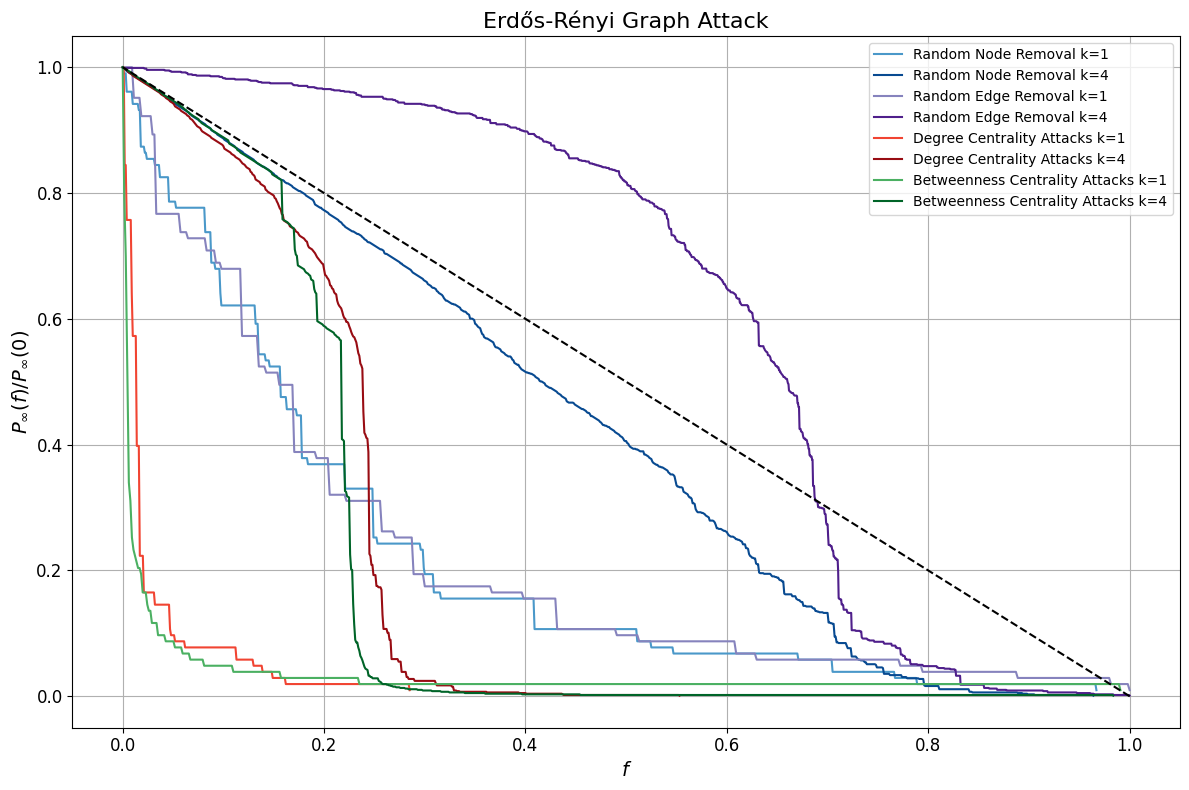

In [8]:
plt.figure(figsize=(12, 8))

for strategy_name, attack_function, cmap_name, type in attack_strategies:
    print(f"{strategy_name}")
    cmap = plt.get_cmap(cmap_name)
    colors = [cmap(ci) for ci in [0.6, 0.9]]
    
    for i, (k, g) in enumerate(er_graphs.items()):
        print(f"Graph k={k}")
        if type == 'node':
            x, y = attack(g, attack_function)
        elif type =='between':
            x,y = attack_between(g)
        else: 
            x, y = attack_edges(g, attack_function)
        plt.plot(x, y, color=colors[i], label=f'{strategy_name} k={k}')

plt.plot([1, 0], [0, 1], 'k--')
plt.legend(fontsize=10)
plt.xlabel(r'$f$', fontsize=14)
plt.ylabel(r'$P_{\infty}(f)/P_{\infty}(0)$', fontsize=14)
plt.title('Erdős-Rényi Graph Attack', fontsize=16)
plt.grid()
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()


Random Node Removal
Graph k=2
Graph k=4
Random Edge Removal
Graph k=2
Graph k=4
Degree Centrality Attacks
Graph k=2
Graph k=4
Betweenness Centrality Attacks
Graph k=2


Attacking nodes:  99%|█████████▉| 989/1000 [00:01<00:00, 505.58node/s]


Graph k=4


Attacking nodes:  93%|█████████▎| 930/1000 [00:06<00:00, 146.32node/s] 


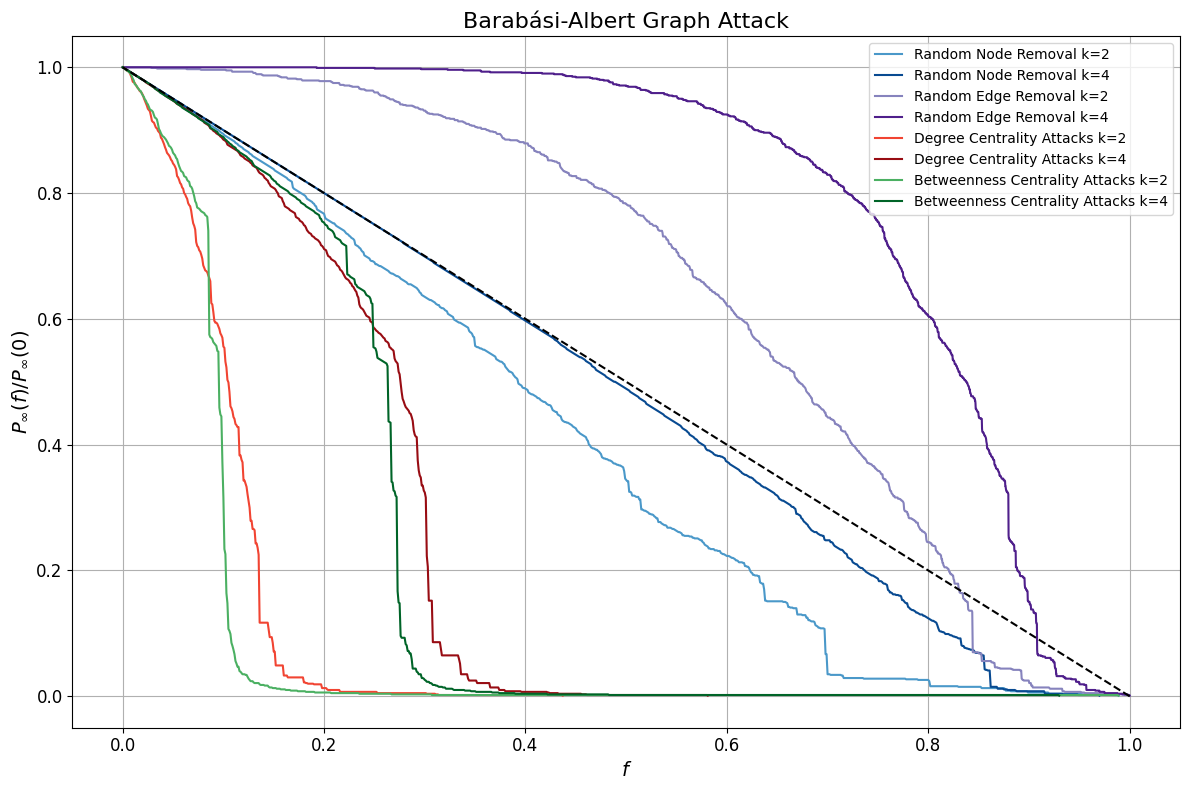

In [9]:
# Initialize the figure
plt.figure(figsize=(12, 8))

for strategy_name, attack_function, cmap_name, type in attack_strategies:
    print(f"{strategy_name}")
    cmap = plt.get_cmap(cmap_name)
    colors = [cmap(ci) for ci in [0.6, 0.9]]
    
    for i, (k, g) in enumerate(ba_graphs.items()):
        print(f"Graph k={k}")
        if type == 'node':
            x, y = attack(g, attack_function)
        elif type =='between':
            x,y = attack_between(g)
        else: 
            x, y = attack_edges(g, attack_function)
        plt.plot(x, y, color=colors[i], label=f'{strategy_name} k={k}')
        
plt.plot([1, 0], [0, 1], 'k--')
plt.legend(fontsize=10)
plt.xlabel(r'$f$', fontsize=14)
plt.ylabel(r'$P_{\infty}(f)/P_{\infty}(0)$', fontsize=14)
plt.title('Barabási-Albert Graph Attack', fontsize=16)
plt.grid()
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()


Random Node Removal
eu_airlines
power
Random Edge Removal
eu_airlines
power
Degree Centrality Attacks
eu_airlines
power
Betweenness Centrality Attacks
eu_airlines


Attacking nodes:  99%|█████████▉| 414/417 [00:00<00:00, 1413.48node/s]


power


Attacking nodes: 100%|█████████▉| 4936/4941 [00:24<00:00, 202.03node/s] 


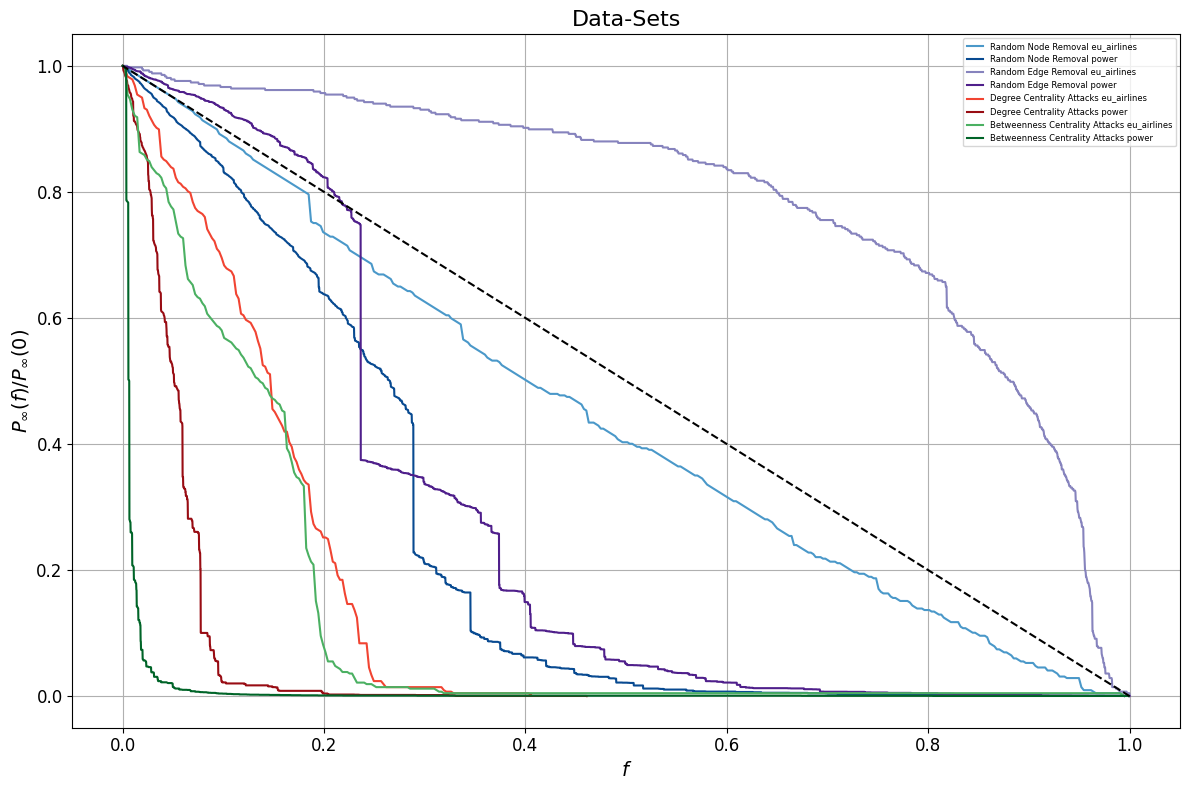

In [10]:
# Initialize the figure
plt.figure(figsize=(12, 8))

for strategy_name, attack_function, cmap_name, type in attack_strategies:
    print(f"{strategy_name}")
    cmap = plt.get_cmap(cmap_name)
    colors = [cmap(ci) for ci in [0.6, 0.9]]
    
    for i, g in enumerate(data_lst):
        print(f"{data_names[i]}")
        if type == 'node':
            x, y = attack(g, attack_function)
        elif type =='between':
            x,y = attack_between(g)
        else: 
            x, y = attack_edges(g, attack_function)     
        plt.plot(x, y, color=colors[i],
                 label=f'{strategy_name} {data_names[i]}')

plt.plot([1, 0], [0, 1], 'k--')
plt.legend(fontsize=6)
plt.xlabel(r'$f$', fontsize=14)
plt.ylabel(r'$P_{\infty}(f)/P_{\infty}(0)$', fontsize=14)
plt.title('Data-Sets', fontsize=16)

plt.grid()
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()
